# Hourly bike-sharing demand — time-series probabilistic forecast

Real time series: 17 379 hourly rows from a DC bike-share system
(2011–2012). Target = hourly rental count. We use **expanding-window
CV** (train always precedes test in calendar time) and compare two
baselines against learned models:

1. `EmpiricalDistribution` — marginal of y; ignores features.
2. `Persistence(lag=24)` — same hour yesterday; captures diurnal cycle.

The interesting question isn't beating the marginal (most models do).
It's beating the **seasonal** one.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd() / "_src"))

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

warnings.filterwarnings(
    "ignore", message="X does not have valid feature names.*",
    category=UserWarning,
)

import matplotlib.pyplot as plt
from _style import (
    color_for,
    predicted_vs_realized_grid,
    reliability_with_histogram,
)
from bracketlearn.baselines import EmpiricalDistribution, Persistence
from bracketlearn.compose import WalkForward
from bracketlearn.lift import GlobalResidual, Isotonic
from bracketlearn.pipeline import Pipeline
from bracketlearn.score import pit, to_point
from bracketlearn.trainers import EMOS, QuantileReg
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Data

In [2]:
print("loading Bike_Sharing_Demand …")
ds = fetch_openml("Bike_Sharing_Demand", version=2,
                  as_frame=True, parser="pandas")
df: pd.DataFrame = ds.data
y_raw = ds.target.to_numpy(dtype=float)
df = df.sort_values(["year", "month", "hour"]).reset_index(drop=True)
y = y_raw[df.index.to_numpy()]


def _prepare(df: pd.DataFrame) -> np.ndarray:
    df = df.copy()
    cat_cols = [c for c in df.columns if str(df[c].dtype) == "category"]
    num_cols = [c for c in df.columns if c not in cat_cols]
    dummies = pd.get_dummies(df[cat_cols], drop_first=True).astype(float)
    X = pd.concat([df[num_cols].astype(float), dummies], axis=1)
    return X.to_numpy(dtype=float)


X = _prepare(df)
n = X.shape[0]
ids = np.arange(n)
ts = ids.astype(float)
print(f"  rows={n}  features={X.shape[1]}  y in [{y.min():.0f}, {y.max():.0f}]")

# Synthetic "ensemble" for EMOS (which expects rows × experts).
rng = np.random.default_rng(0)
temp_col = df["temp"].to_numpy(dtype=float)
X_ens = np.column_stack([
    temp_col + rng.normal(0, 1, n),
    temp_col + rng.normal(0, 2, n),
    temp_col + rng.normal(0, 0.5, n),
]) * 8.0 + 50.0

loading Bike_Sharing_Demand …
  rows=17379  features=16  y in [1, 977]


**Diurnal + weekly cycle** — first 14 days. This is why lag-24
persistence is a meaningful baseline, not a strawman.

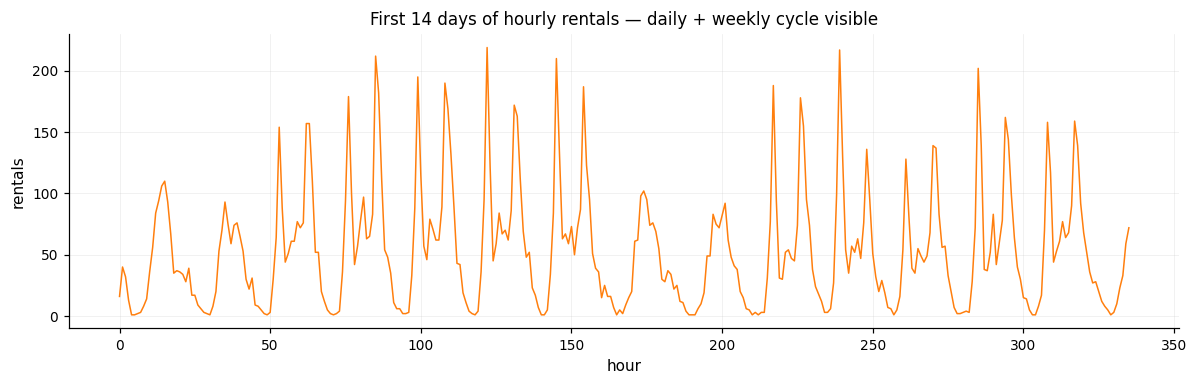

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.6))
sample = df.iloc[:24 * 14]
ax.plot(sample.index, y[:24 * 14], color=color_for("qreg"), lw=1.0)
ax.set_xlabel("hour")
ax.set_ylabel("rentals")
ax.set_title("First 14 days of hourly rentals — daily + weekly cycle visible")
fig.tight_layout()
plt.show()

## Bracket ladder

In [4]:
edges = np.array([0., 50., 100., 200., 350., 500., 750., 1000.])
print(f"{len(edges)-1} brackets covering {edges[0]:.0f}–{edges[-1]:.0f} bikes/hour")

7 brackets covering 0–1000 bikes/hour


## Pipeline: 2 baselines + 2 learned models

`embargo=24` puts a 24-row buffer between train and test in each fold,
so persistence-style leakage across the boundary is ruled out.

In [5]:
model = [
    Pipeline([EmpiricalDistribution()], name="emp"),
    Pipeline([Persistence(lag=24), GlobalResidual()], name="persist24"),
    Pipeline([EMOS(), Isotonic(pre_integrate_edges=edges)], name="emos_iso"),
    Pipeline([QuantileReg(n_estimators=200, learning_rate=0.05, random_seed=0)], name="qreg"),
]
wf = WalkForward(
    cv="expanding-window", n_folds=5, embargo=24, refit_on_full=False,
)
result = wf.fit_predict(model, X_ens, y, ids=ids, timestamps=ts)
print(result.to_table(y, metrics=["crps", "log_score", "pit"]))

/Users/frederik/Github/QuantDevelopment/Python/PredictionMarketClient/bracketlearn/pipeline.py:218: UserWarning: EMOS(fit_method='ols'): linear-in-variance fit gave non-positive variance (c=7.75e+03, d=-0.439); fell back to constant σ²=7.72e+03. ens_var is not informative about residual scale on this training set — consider EMOS(fit_method='crps_nelder_mead') (exp-link variance) or check ensemble spread-skill.
  forecaster.fit(X, y, **call_kwargs)


/Users/frederik/Github/QuantDevelopment/Python/PredictionMarketClient/bracketlearn/pipeline.py:218: UserWarning: EMOS(fit_method='ols'): linear-in-variance fit gave non-positive variance (c=2.08e+04, d=-2.06); fell back to constant σ²=2.06e+04. ens_var is not informative about residual scale on this training set — consider EMOS(fit_method='crps_nelder_mead') (exp-link variance) or check ensemble spread-skill.
  forecaster.fit(X, y, **call_kwargs)


/Users/frederik/Github/QuantDevelopment/Python/PredictionMarketClient/bracketlearn/pipeline.py:218: UserWarning: EMOS(fit_method='ols'): linear-in-variance fit gave non-positive variance (c=2.74e+04, d=-3.61); fell back to constant σ²=2.72e+04. ens_var is not informative about residual scale on this training set — consider EMOS(fit_method='crps_nelder_mead') (exp-link variance) or check ensemble spread-skill.
  forecaster.fit(X, y, **call_kwargs)


stage              n_oof          crps     log_score      pit_mean       pit_std
--------------------------------------------------------------------------------
emp                14459      107.0479        6.1739        0.6061        0.3158
persist24          14459      102.1141        6.6693        0.5136        0.2704
emos_iso           14459      100.3318        8.7278        0.4804        0.3199
qreg               14459      103.4369        6.0337        0.5922        0.3277


## Headline diagnostic — predicted vs realized

Same sklearn-style scatter grid as the housing notebook, four panels.
`emp` collapses onto one horizontal stripe. `persist24` clusters along
the diagonal but with wide noise (yesterday isn't tomorrow). `qreg`
tracks the diagonal across the full range; `emos_iso` is limited
because its input is a temperature-jitter ensemble, not features.

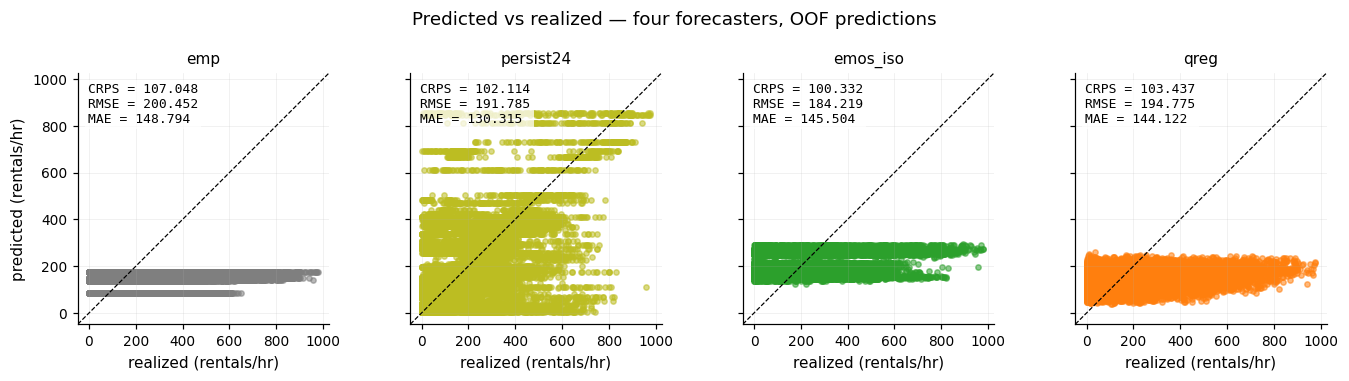

In [6]:
crps_scores = result.score(y, metrics=["crps"])
panels = []
for name in ["emp", "persist24", "emos_iso", "qreg"]:
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    mu = to_point(dist, how="mean")
    panels.append((name, mu, y_oof, {
        "CRPS": float(crps_scores[name]["crps"]),
        "RMSE": float(np.sqrt(mean_squared_error(y_oof, mu))),
        "MAE":  float(mean_absolute_error(y_oof, mu)),
    }))

fig = predicted_vs_realized_grid(
    panels, ncols=4, units="rentals/hr",
    figsize_per_panel=(3.2, 3.2),
    title="Predicted vs realized — four forecasters, OOF predictions",
)
plt.show()

## PIT histograms

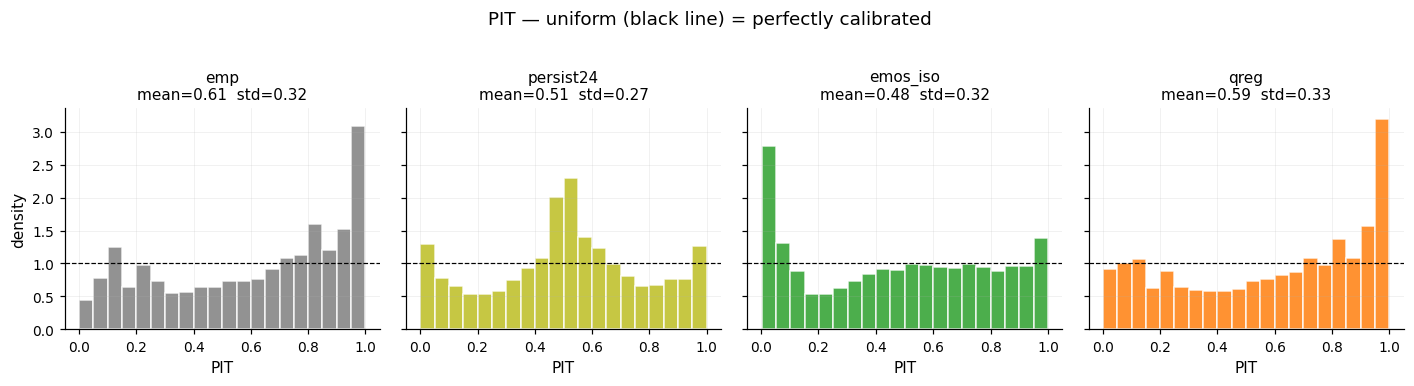

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for ax, name in zip(axes, ["emp", "persist24", "emos_iso", "qreg"], strict=True):
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    pit_vals = pit(dist, y_oof)
    ax.hist(pit_vals, bins=20, color=color_for(name),
            edgecolor="white", density=True, alpha=0.85)
    ax.axhline(1.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{name}\nmean={pit_vals.mean():.2f}  std={pit_vals.std():.2f}",
                 fontsize=10)
    ax.set_xlabel("PIT")
axes[0].set_ylabel("density")
fig.suptitle("PIT — uniform (black line) = perfectly calibrated", y=1.02)
fig.tight_layout()
plt.show()

## Predicted bands over time

7 days of held-out forecasts from QuantileReg, with the 10–90 % band,
its median, the persistence-24 mean, and the realised series.

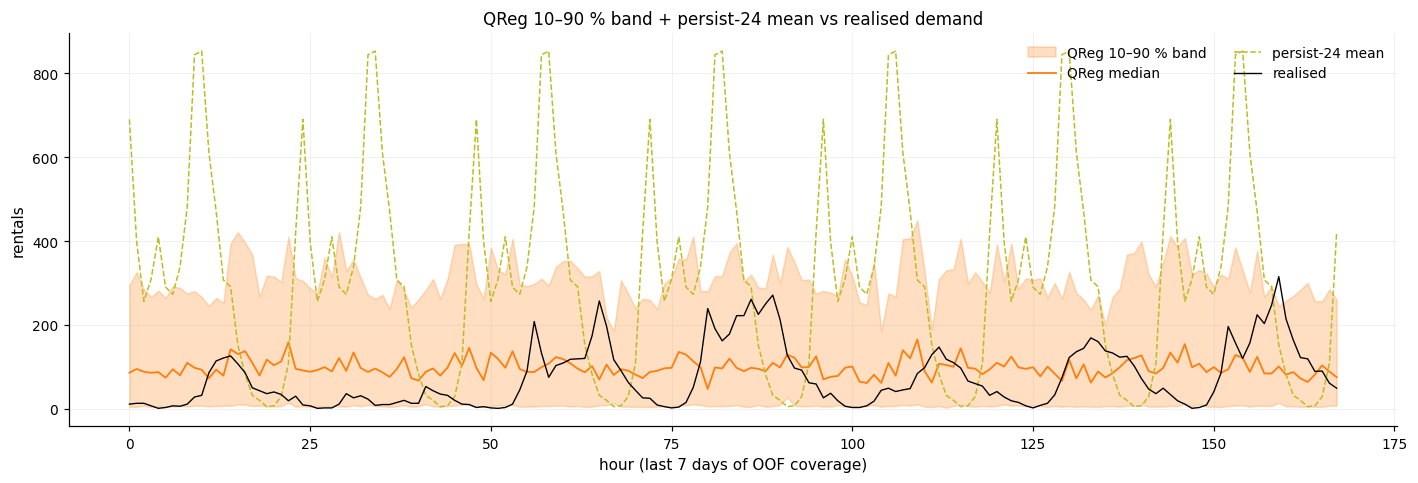

In [8]:
dist_qreg = result["qreg"]
dist_per = result["persist24"]
ids_qreg = dist_qreg.ids.astype(int)
ids_per = dist_per.ids.astype(int)
common = np.intersect1d(ids_qreg, ids_per)
last_week = common[-24 * 7:]
pos_q = np.searchsorted(ids_qreg, last_week)
pos_p = np.searchsorted(ids_per, last_week)
taus = dist_qreg.taus
i_lo, i_md, i_hi = (np.argmin(np.abs(taus - q)) for q in (0.1, 0.5, 0.9))

xs = np.arange(last_week.size)
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.fill_between(xs,
                dist_qreg.qvals[pos_q, i_lo],
                dist_qreg.qvals[pos_q, i_hi],
                alpha=0.25, color=color_for("qreg"),
                label="QReg 10–90 % band")
ax.plot(xs, dist_qreg.qvals[pos_q, i_md], color=color_for("qreg"),
        lw=1.2, label="QReg median")
ax.plot(xs, dist_per.params["mu"][pos_p], color=color_for("persist24"),
        lw=1.0, linestyle="--", label="persist-24 mean")
ax.plot(xs, y[last_week], color="black", lw=0.9, label="realised")
ax.set_xlabel("hour (last 7 days of OOF coverage)")
ax.set_ylabel("rentals")
ax.set_title("QReg 10–90 % band + persist-24 mean vs realised demand")
ax.legend(loc="upper right", ncol=2)
fig.tight_layout()
plt.show()

## Hour-of-day calibration heatmap

A new diagnostic: how does the QReg PIT distribution look at each hour
of the day? Each row = one hour-of-day bin. Each column = a PIT bin.
A perfectly calibrated forecast has uniform colour across every row.
Bright stripes in the corners = certain hours are systematically
over/under-predicted.

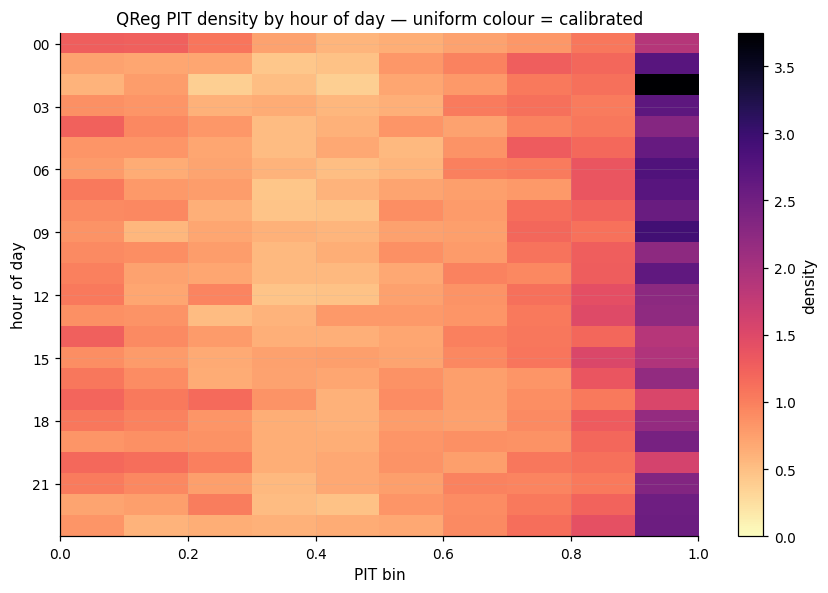

In [9]:
hour = df["hour"].to_numpy()
y_q = y[ids_qreg]
hour_q = hour[ids_qreg]
pit_q = pit(dist_qreg, y_q)

# 24 hours × 10 PIT bins.
H, P = 24, 10
heat = np.zeros((H, P))
for h in range(H):
    sel = hour_q == h
    if sel.any():
        heat[h], _ = np.histogram(pit_q[sel], bins=np.linspace(0, 1, P + 1),
                                  density=True)

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(heat, aspect="auto", cmap="magma_r",
               extent=(0, 1, H, 0), vmin=0, vmax=heat.max())
ax.set_xlabel("PIT bin")
ax.set_ylabel("hour of day")
ax.set_yticks(np.arange(0, 24, 3) + 0.5,
              labels=[f"{h:02d}" for h in range(0, 24, 3)])
ax.set_title("QReg PIT density by hour of day — uniform colour = calibrated")
fig.colorbar(im, ax=ax, label="density")
fig.tight_layout()
plt.show()

## Reliability — bracket probabilities calibrated?

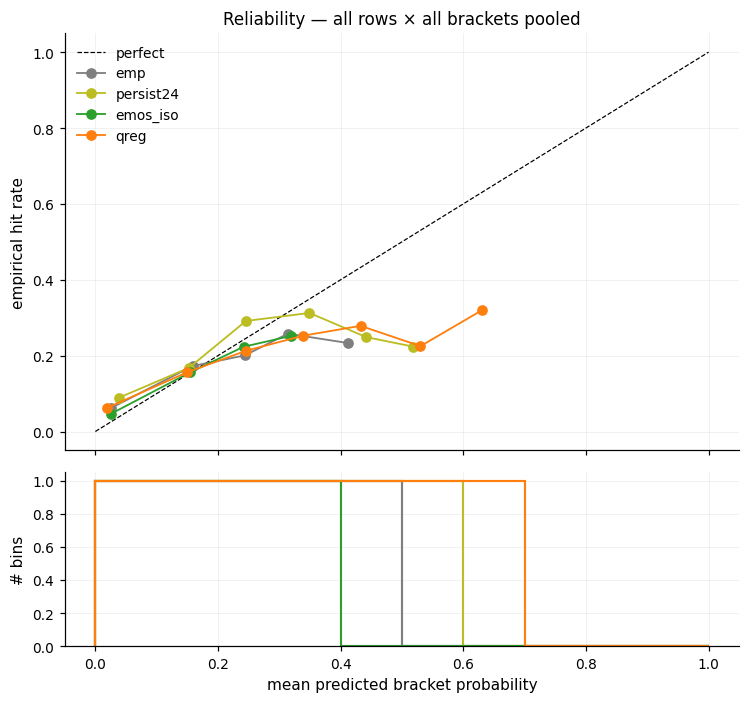

In [10]:
def _reliability(dist, edges, y_oof, n_bins=10):
    cdf_hi = dist.cdf(edges[1:])
    cdf_lo = dist.cdf(edges[:-1])
    probs = np.clip(cdf_hi - cdf_lo, 0, 1)
    bin_idx = np.searchsorted(edges, y_oof, side="right") - 1
    bin_idx = np.clip(bin_idx, 0, probs.shape[1] - 1)
    realized = np.zeros_like(probs)
    realized[np.arange(probs.shape[0]), bin_idx] = 1.0
    p_flat = probs.reshape(-1)
    r_flat = realized.reshape(-1)
    edges_p = np.linspace(0, 1, n_bins + 1)
    means, hits = [], []
    for i in range(n_bins):
        mask = (p_flat >= edges_p[i]) & (p_flat < edges_p[i + 1] + (i == n_bins - 1))
        if mask.sum() < 5:
            continue
        means.append(p_flat[mask].mean())
        hits.append(r_flat[mask].mean())
    return np.array(means), np.array(hits)


series = []
for name in ["emp", "persist24", "emos_iso", "qreg"]:
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    mp, hr = _reliability(dist, edges, y_oof)
    series.append((name, mp, hr))
fig = reliability_with_histogram(
    series, title="Reliability — all rows × all brackets pooled",
)
plt.show()

## Leaderboard

/Users/frederik/Github/QuantDevelopment/Python/PredictionMarketClient/bracketlearn/pipeline.py:218: UserWarning: EMOS(fit_method='ols'): linear-in-variance fit gave non-positive variance (c=7.75e+03, d=-0.439); fell back to constant σ²=7.72e+03. ens_var is not informative about residual scale on this training set — consider EMOS(fit_method='crps_nelder_mead') (exp-link variance) or check ensemble spread-skill.
  forecaster.fit(X, y, **call_kwargs)


/Users/frederik/Github/QuantDevelopment/Python/PredictionMarketClient/bracketlearn/pipeline.py:218: UserWarning: EMOS(fit_method='ols'): linear-in-variance fit gave non-positive variance (c=2.08e+04, d=-2.06); fell back to constant σ²=2.06e+04. ens_var is not informative about residual scale on this training set — consider EMOS(fit_method='crps_nelder_mead') (exp-link variance) or check ensemble spread-skill.
  forecaster.fit(X, y, **call_kwargs)


/Users/frederik/Github/QuantDevelopment/Python/PredictionMarketClient/bracketlearn/pipeline.py:218: UserWarning: EMOS(fit_method='ols'): linear-in-variance fit gave non-positive variance (c=2.74e+04, d=-3.61); fell back to constant σ²=2.72e+04. ens_var is not informative about residual scale on this training set — consider EMOS(fit_method='crps_nelder_mead') (exp-link variance) or check ensemble spread-skill.
  forecaster.fit(X, y, **call_kwargs)


rank model                   CRPS    vs emp   vs P-24
-----------------------------------------------------
1    EMOS+Iso              100.33    +0.063    +0.017
2    QuantileReg           100.82    +0.058    +0.013
3    Persist-24            102.11    +0.046    +0.000
4    CumBinary             102.66    +0.041    -0.005
5    Empirical             107.05    +0.000    -0.048
6    Persist-168           107.45    -0.004    -0.052
7    Persist-1             130.29    -0.217    -0.276


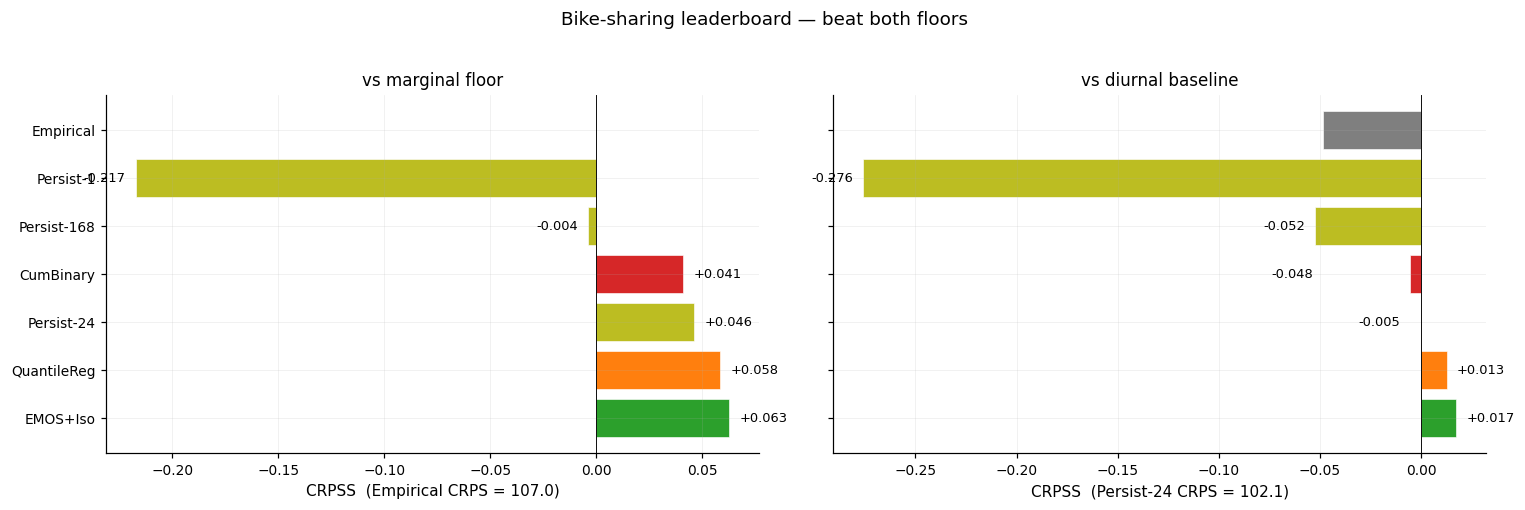

In [11]:
from bracketlearn.trainers import CumulativeBinary

cuts = edges[1:-1]
# CumulativeBinary takes per-row grids (v0.3 per-row brackets); bike uses one
# shared grid, so map every row id to the same cutpoints / outer-edge pair.
_cut_by_id = {int(i): cuts for i in ids}
_outer_by_id = {int(i): (float(edges[0]), float(edges[-1])) for i in ids}


def _score_one(stage_name, forecaster, x_in=None):
    m = forecaster if isinstance(forecaster, Pipeline) else Pipeline([forecaster], name=stage_name)
    r = WalkForward(
        cv="expanding-window", n_folds=5, embargo=24, refit_on_full=False,
    ).fit_predict(m, x_in if x_in is not None else X_ens, y, ids=ids, timestamps=ts)
    return r.score(y, metrics=["crps"])[m.name]["crps"]


lb = {
    "Empirical":      _score_one("emp", EmpiricalDistribution()),
    "Persist-1":      _score_one("p1", Pipeline(
        [Persistence(lag=1), GlobalResidual()], name="p1",
    )),
    "Persist-24":     _score_one("p24", Pipeline(
        [Persistence(lag=24), GlobalResidual()], name="p24",
    )),
    "Persist-168":    _score_one("p168", Pipeline(
        [Persistence(lag=168), GlobalResidual()], name="p168",
    )),
    "EMOS+Iso":       _score_one("emos_iso", Pipeline(
        [EMOS(), Isotonic(pre_integrate_edges=edges)], name="emos_iso",
    )),
    "QuantileReg":    _score_one("qreg", QuantileReg(
        n_estimators=200, learning_rate=0.05, random_seed=0,
    ), x_in=X),
    "CumBinary":      _score_one("cum", CumulativeBinary(
        cutpoints_by_id=_cut_by_id, outer_edges_by_id=_outer_by_id,
        n_estimators=80,
    ), x_in=X),
}

rows = sorted(lb.items(), key=lambda kv: kv[1])
base_emp = lb["Empirical"]
seas = lb["Persist-24"]
print(f"{'rank':<5}{'model':<18}{'CRPS':>10}{'vs emp':>10}{'vs P-24':>10}")
print("-" * 53)
for i, (name, c) in enumerate(rows, 1):
    print(f"{i:<5}{name:<18}{c:>10.2f}"
          f"{1-c/base_emp:>+10.3f}{1-c/seas:>+10.3f}")

# Two side-by-side leaderboard bars: vs Empirical, vs Persist-24.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, (base_name, base_v, suffix) in zip(
    axes,
    [("Empirical", base_emp, "vs marginal floor"),
     ("Persist-24", seas, "vs diurnal baseline")],
    strict=True,
):
    items = [(n, v) for n, v in rows if n != base_name]
    skills = [(n, 1.0 - v / base_v) for n, v in items]
    skills.sort(key=lambda p: -p[1])
    names = [s[0] for s in skills]
    vals = [s[1] for s in skills]
    colors = [color_for(n) for n in names]
    ax.barh(names, vals, color=colors, edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="black", lw=0.6)
    ax.invert_yaxis()
    ax.set_xlabel(f"CRPSS  ({base_name} CRPS = {base_v:.1f})")
    ax.set_title(suffix)
    for i, s in enumerate(vals):
        ax.text(s + (0.005 if s > 0 else -0.005), i, f"{s:+.3f}",
                va="center", ha="left" if s > 0 else "right", fontsize=8.5)
fig.suptitle("Bike-sharing leaderboard — beat both floors", y=1.02)
fig.tight_layout()
plt.show()

## Point-forecast benchmark vs sklearn

Same scatter-grid format from the housing notebook — probabilistic
means side by side with classical regressors.

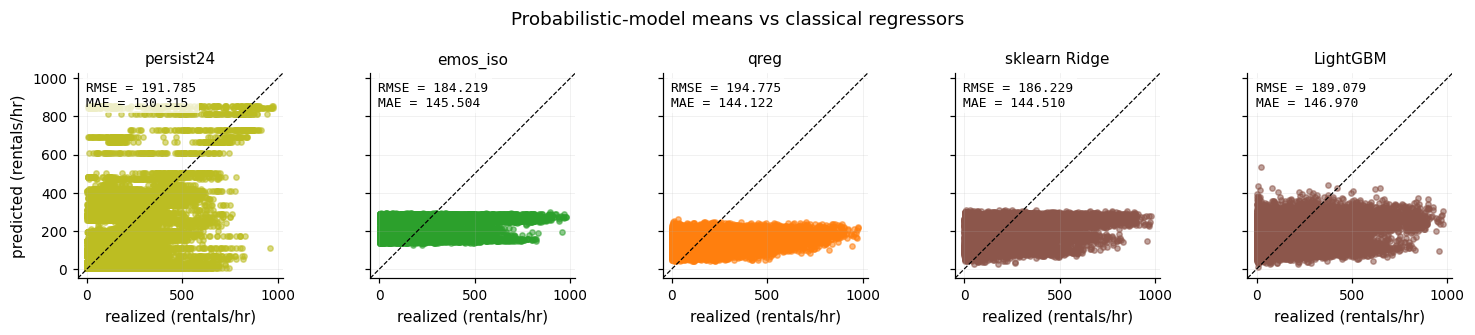

In [12]:
from bracketlearn.score import to_point
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit


def _sklearn_oof(model_factory, X_in):
    tss = TimeSeriesSplit(n_splits=5)
    preds = np.full(y.size, np.nan)
    for tr, te in tss.split(X_in):
        m = model_factory()
        m.fit(X_in[tr], y[tr])
        preds[te] = m.predict(X_in[te])
    return preds


ridge_pred = _sklearn_oof(lambda: Ridge(alpha=1.0), X)
lgb_pred = _sklearn_oof(
    lambda: LGBMRegressor(n_estimators=200, learning_rate=0.05,
                          verbose=-1, random_state=0),
    X,
)

point_panels = []
for name in ["persist24", "emos_iso", "qreg"]:
    dist = result[name]
    y_oof = y[dist.ids.astype(int)]
    mu = to_point(dist, how="mean")
    point_panels.append((name, mu, y_oof, {
        "RMSE": float(np.sqrt(mean_squared_error(y_oof, mu))),
        "MAE":  float(mean_absolute_error(y_oof, mu)),
    }))

# Pad sklearn rows (they cover the full y; just align).
for name, preds in [("sklearn Ridge", ridge_pred), ("LightGBM", lgb_pred)]:
    mask = ~np.isnan(preds)
    point_panels.append((name, preds[mask], y[mask], {
        "RMSE": float(np.sqrt(mean_squared_error(y[mask], preds[mask]))),
        "MAE":  float(mean_absolute_error(y[mask], preds[mask])),
    }))

fig = predicted_vs_realized_grid(
    point_panels, ncols=5, units="rentals/hr",
    figsize_per_panel=(2.8, 2.8),
    title="Probabilistic-model means vs classical regressors",
)
plt.show()